In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print("Using device:", device)


Using device: cpu


In [2]:
train_transform = transforms.Compose([
    transforms.Resize((28, 28)), #same size
    transforms.RandomRotation(15), # push accuracy > 90% | Data Augmentation
    transforms.ToTensor(),  #image file (pixels) into a Tensor
    transforms.Normalize((0.5,), (0.5,))  # Mean of 0.5 and a standard deviation of 0.5-> [-1,1]
])

test_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# DATASET & LOADING 
class QuickDrawDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        self.class_to_idx = {}

        # Scan directories to map folder names to numbers (labels)
        classes = sorted(os.listdir(root_dir))
        for idx, cls in enumerate(classes):
            self.class_to_idx[cls] = idx
            cls_path = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_path): continue
            for file in os.listdir(cls_path):
                if file.endswith(".png"):
                    self.samples.append((os.path.join(cls_path, file), idx))

    def __len__(self):
        return len(self.samples)
       

    def __getitem__(self, idx):
        path, label = self.samples[idx] 
        image = Image.open(path).convert("L") #This forces it into 1-channel Grayscale
        if self.transform:
            image = self.transform(image)
        return image, label


# Load and split
full_dataset = QuickDrawDataset("../data/", transform=None) # Raw loading
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_subset, test_subset = random_split(full_dataset, [train_size, test_size])

# Re-apply specific transforms to the subsets
train_subset.dataset.transform = train_transform
test_subset.dataset.transform = test_transform

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=128, shuffle=False)
print(f"Total images found: {len(full_dataset)}")
print(f"Number of classes: {len(full_dataset.class_to_idx)}")



Total images found: 9900
Number of classes: 100


In [3]:
# MODEL ARCHITECTURE 

class QuickDrawCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Added BatchNorm2d to every layer to speed up learning and stabilize gradients
        self.features = nn.Sequential(   #Feature Extractor
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32), # Normalizes data for faster training
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), 
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Fully Connected (Dense) Layer
        self.classifier = nn.Sequential(
            nn.Linear(128 * 3 * 3, 512), # Increased from 256 to 512 for more 'memory' |learn complex relationships between features
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1) # Flatten
        return self.classifier(x)

model = QuickDrawCNN(len(full_dataset.class_to_idx)).to(device)

In [4]:
# TRAINING ENGINE
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning Rate Scheduler: Decreases LR when progress plateaus
#If the model stops improving for 2 rounds (patience=2), the scheduler slows down the learning rate.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

epochs = 10
history = {'loss': [], 'test_loss': [], 'acc': [], 'test_acc': []}

# x Shape: [128, 1 (grayscale), 28, 28]
# y Shape: [128]

for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * x.size(0)  #average error for the current batch * 128
        _, pred = out.max(1) # finds the highest score among 100 class | _ : the value of highest score | pred : the index 
        correct += (pred == y).sum().item()
        total += y.size(0)

    # Validation
    model.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            v_loss += criterion(out, y).item() * x.size(0)
            _, pred = out.max(1)
            v_correct += (pred == y).sum().item()
            v_total += y.size(0)
    
    # Track stats
    epoch_v_loss = v_loss / v_total
    history['loss'].append(total_loss / total)
    history['test_loss'].append(epoch_v_loss)
    history['acc'].append(correct / total)
    history['test_acc'].append(v_correct / v_total)
    
    scheduler.step(epoch_v_loss) # Adjust LR based on validation loss
    print(f"Epoch {epoch+1}: Train Acc {history['acc'][-1]:.3f} | Test Acc {history['test_acc'][-1]:.3f}")


torch.save(model.state_dict(), "model.pth")

Epoch 1: Train Acc 0.289 | Test Acc 0.616
Epoch 2: Train Acc 0.765 | Test Acc 0.913
Epoch 3: Train Acc 0.883 | Test Acc 0.941
Epoch 4: Train Acc 0.923 | Test Acc 0.964
Epoch 5: Train Acc 0.940 | Test Acc 0.961
Epoch 6: Train Acc 0.952 | Test Acc 0.964
Epoch 7: Train Acc 0.964 | Test Acc 0.961
Epoch 8: Train Acc 0.968 | Test Acc 0.964
Epoch 9: Train Acc 0.974 | Test Acc 0.958
Epoch 10: Train Acc 0.979 | Test Acc 0.969


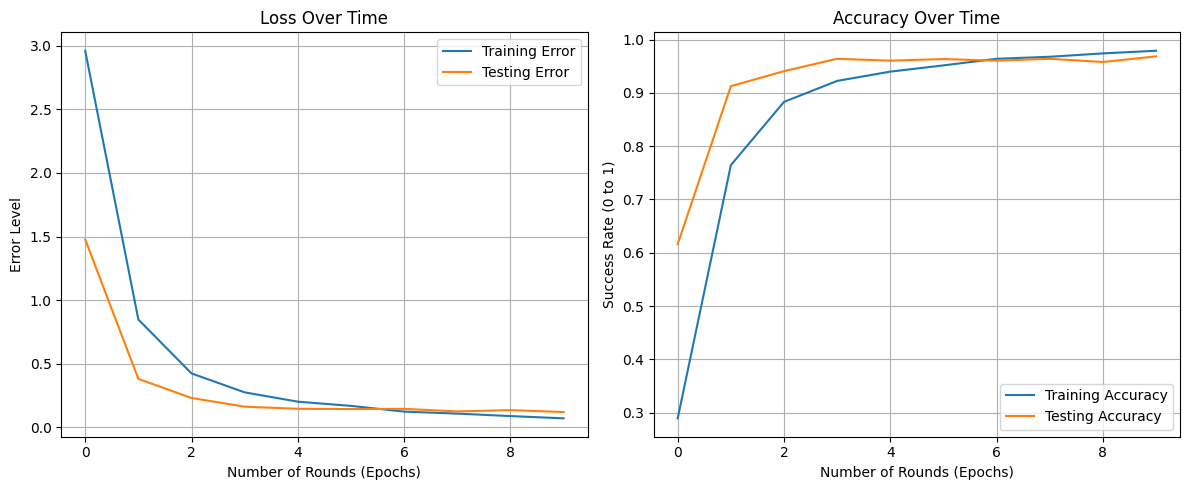

<Figure size 640x480 with 0 Axes>

In [5]:
# VISUALIZING THE RESULTS

plt.figure(figsize=(12, 5))

# Left Graph: The Loss 
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Error')
plt.plot(history['test_loss'], label='Testing Error')
plt.title('Loss Over Time')
plt.xlabel('Number of Rounds (Epochs)')
plt.ylabel('Error Level')
plt.legend() 
plt.grid(True)

# Right Graph: The Accuracy 
plt.subplot(1, 2, 2) 
plt.plot(history['acc'], label='Training Accuracy')
plt.plot(history['test_acc'], label='Testing Accuracy')
plt.title('Accuracy Over Time')
plt.xlabel('Number of Rounds (Epochs)')
plt.ylabel('Success Rate (0 to 1)')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()


plt.savefig('my_results.png')


In [22]:
# FINAL EXPLICIT TEST ACCURACY 

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total
print("FINAL TEST ACCURACY:", test_accuracy)


FINAL TEST ACCURACY: 0.9686868686868687
